# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: KNN Classification on Breast Cancer Dataset & Comparison with Regression Metrics

**Aim:** To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset — 569 samples, 30 numerical features, Target: 0 = Malignant, 1 = Benign (as loaded via `sklearn.datasets.load_breast_cancer`).

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
np.random.seed(42)

## Task 1: Data Preparation

In [2]:
# 1. Load the dataset using sklearn
data = load_breast_cancer()

# 2. Convert into DataFrame and explore structure
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Explore structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Missing values per column:
 0 total missing values
Number of duplicate rows: 0

Class distribution (0=Malignant, 1=Benign):
target
1    357
0    212
Name: count, dtype: int64


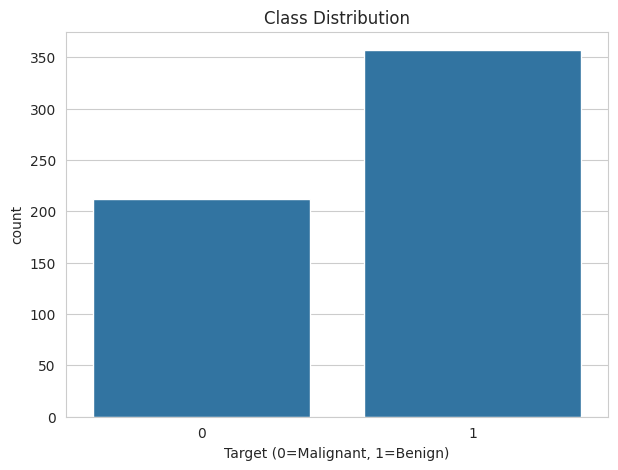

In [5]:
# 3. Check missing values and duplicates
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("Number of duplicate rows:", df.duplicated().sum())

print("\nClass distribution (0=Malignant, 1=Benign):")
print(df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.xlabel("Target (0=Malignant, 1=Benign)")
plt.show()

In [6]:
# 4. Apply feature scaling using StandardScaler
X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (sample column 'mean radius'):")
print(X['mean radius'].describe()[['mean','std','min','max']])
print("\nAfter scaling (sample column 'mean radius'):")
print(X_scaled['mean radius'].describe()[['mean','std','min','max']])

Before scaling (sample column 'mean radius'):
mean    14.127292
std      3.524049
min      6.981000
max     28.110000
Name: mean radius, dtype: float64

After scaling (sample column 'mean radius'):
mean   -1.373633e-16
std     1.000880e+00
min    -2.029648e+00
max     3.971288e+00
Name: mean radius, dtype: float64


**Why feature scaling is important for KNN:**

KNN is a distance-based algorithm — it classifies a point based on the Euclidean/Manhattan distance to its neighbours. If features are on very different scales (e.g., "mean area" can be in the hundreds while "mean smoothness" is a small decimal), the feature with the larger numeric range will dominate the distance calculation, even if it isn't more informative. `StandardScaler` transforms every feature to have mean 0 and standard deviation 1, ensuring all features contribute proportionally to the distance metric and the model isn't biased toward high-magnitude features.

## Task 2: Train-Test Split Analysis

Split 80:20 -> Train size: 455, Test size: 114, Accuracy (K=5): 0.9649
Split 70:30 -> Train size: 398, Test size: 171, Accuracy (K=5): 0.9708
Split 90:10 -> Train size: 512, Test size: 57, Accuracy (K=5): 0.9825


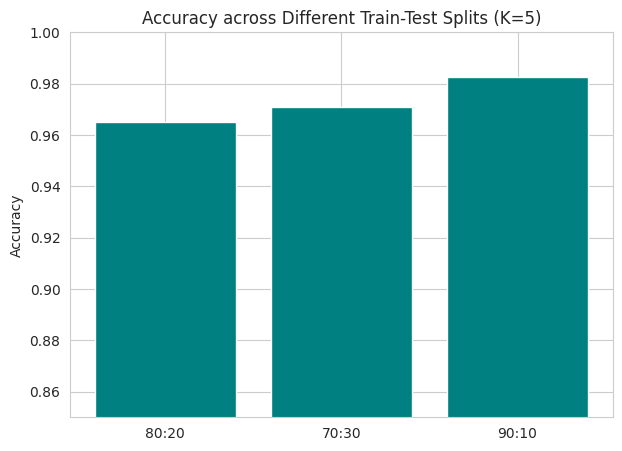

In [7]:
# 1-3. Split dataset into 80:20, 70:30, 90:10 and compare performance
split_ratios = {'80:20': 0.20, '70:30': 0.30, '90:10': 0.10}
split_results = {}

for name, test_size in split_ratios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    knn_temp = KNeighborsClassifier(n_neighbors=5)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    acc = accuracy_score(y_test, y_pred_temp)
    split_results[name] = acc
    print(f"Split {name} -> Train size: {len(X_train)}, Test size: {len(X_test)}, Accuracy (K=5): {acc:.4f}")

plt.bar(split_results.keys(), split_results.values(), color='teal')
plt.ylabel("Accuracy")
plt.title("Accuracy across Different Train-Test Splits (K=5)")
plt.ylim(0.85, 1.0)
plt.show()

**Observation:** Accuracy varies slightly across the 80:20, 70:30 and 90:10 splits. Smaller test sets (90:10) can show higher or more volatile accuracy because the test set is small and less statistically reliable, while larger test sets (70:30) give a more stable but sometimes slightly lower estimate since the model is trained on less data. This shows that a single train-test split can be sensitive to how the data happens to be divided — motivating the use of cross-validation (Task 4) for a more robust estimate of model performance and generalization.

In [8]:
# Fix the primary 80:20 split for the rest of the lab
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print("Final Train shape:", X_train.shape, " Test shape:", X_test.shape)

Final Train shape: (455, 30)  Test shape: (114, 30)


## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic Method for K Selection

In [9]:
# K = sqrt(n), where n = number of training samples
n_train = X_train.shape[0]
k_heuristic = int(np.sqrt(n_train))
if k_heuristic % 2 == 0:   # prefer odd K to avoid ties in binary classification
    k_heuristic += 1

print(f"Number of training samples (n): {n_train}")
print(f"Heuristic K = sqrt(n) = {np.sqrt(n_train):.2f} -> rounded (odd) K = {k_heuristic}")

Number of training samples (n): 455
Heuristic K = sqrt(n) = 21.33 -> rounded (odd) K = 21


### 3.2 Model Training

Baseline Accuracy with heuristic K=21: 0.9561


     K  Accuracy
0   16  0.973684
1   17  0.973684
2   18  0.982456
3   19  0.973684
4   20  0.964912
5   21  0.956140
6   22  0.956140
7   23  0.964912
8   24  0.956140
9   25  0.964912
10  26  0.956140


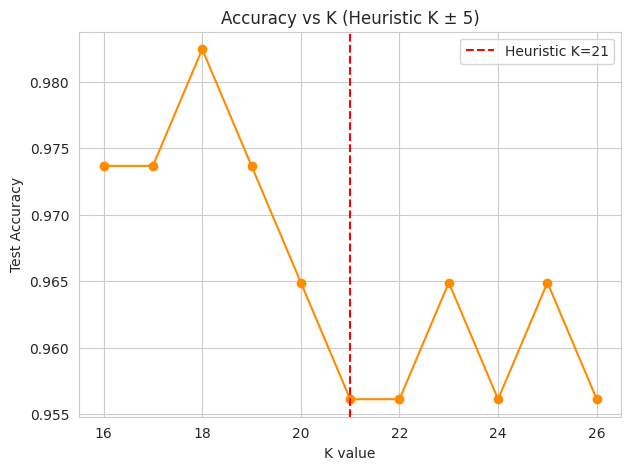


Optimal K in this range based on test accuracy: 18


In [10]:
# Train baseline KNN using heuristic K
knn_base = KNeighborsClassifier(n_neighbors=k_heuristic)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)
print(f"Baseline Accuracy with heuristic K={k_heuristic}: {accuracy_score(y_test, y_pred_base):.4f}")

# Experiment with nearby K values (K ± 5)
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

results_df = pd.DataFrame({'K': list(k_range), 'Accuracy': accuracies})
print(results_df)

# Plot accuracy vs K
plt.plot(list(k_range), accuracies, marker='o', color='darkorange')
plt.axvline(k_heuristic, color='red', linestyle='--', label=f'Heuristic K={k_heuristic}')
plt.xlabel("K value")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (Heuristic K ± 5)")
plt.legend()
plt.show()

optimal_k_local = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nOptimal K in this range based on test accuracy: {optimal_k_local}")

**Identifying optimal K:** From the accuracy-vs-K plot, the optimal K is the one that gives the highest test accuracy while avoiding overfitting (very small K, e.g. K=1) or underfitting (very large K, which oversmooths the decision boundary). The heuristic √n rule gives a reasonable **starting point**, and the local search around it (K ± 5) lets us fine-tune to the actual best-performing K on this dataset.

### 3.3 Distance Metrics and Decision Boundary Mapping

**Euclidean Distance:**
$$d(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$
This measures the straight-line ("as the crow flies") distance between two points in feature space. It is the default and most common metric in KNN. It is well-suited when features are continuous, roughly similarly scaled (after standardization), and the geometry of the data is genuinely Euclidean — e.g., dense numerical data like the Breast Cancer dataset's tumor measurements.

**Manhattan Distance:**
$$d(p,q) = \sum_{i=1}^{n}|p_i - q_i|$$
This measures distance as the sum of absolute differences along each axis (like navigating a grid of city blocks). It is more robust to outliers than Euclidean distance (since differences aren't squared) and tends to work better in high-dimensional spaces or when features represent counts/grid-like movements. It is often preferred when the data has many dimensions or contains outliers that would otherwise dominate a squared-distance metric.

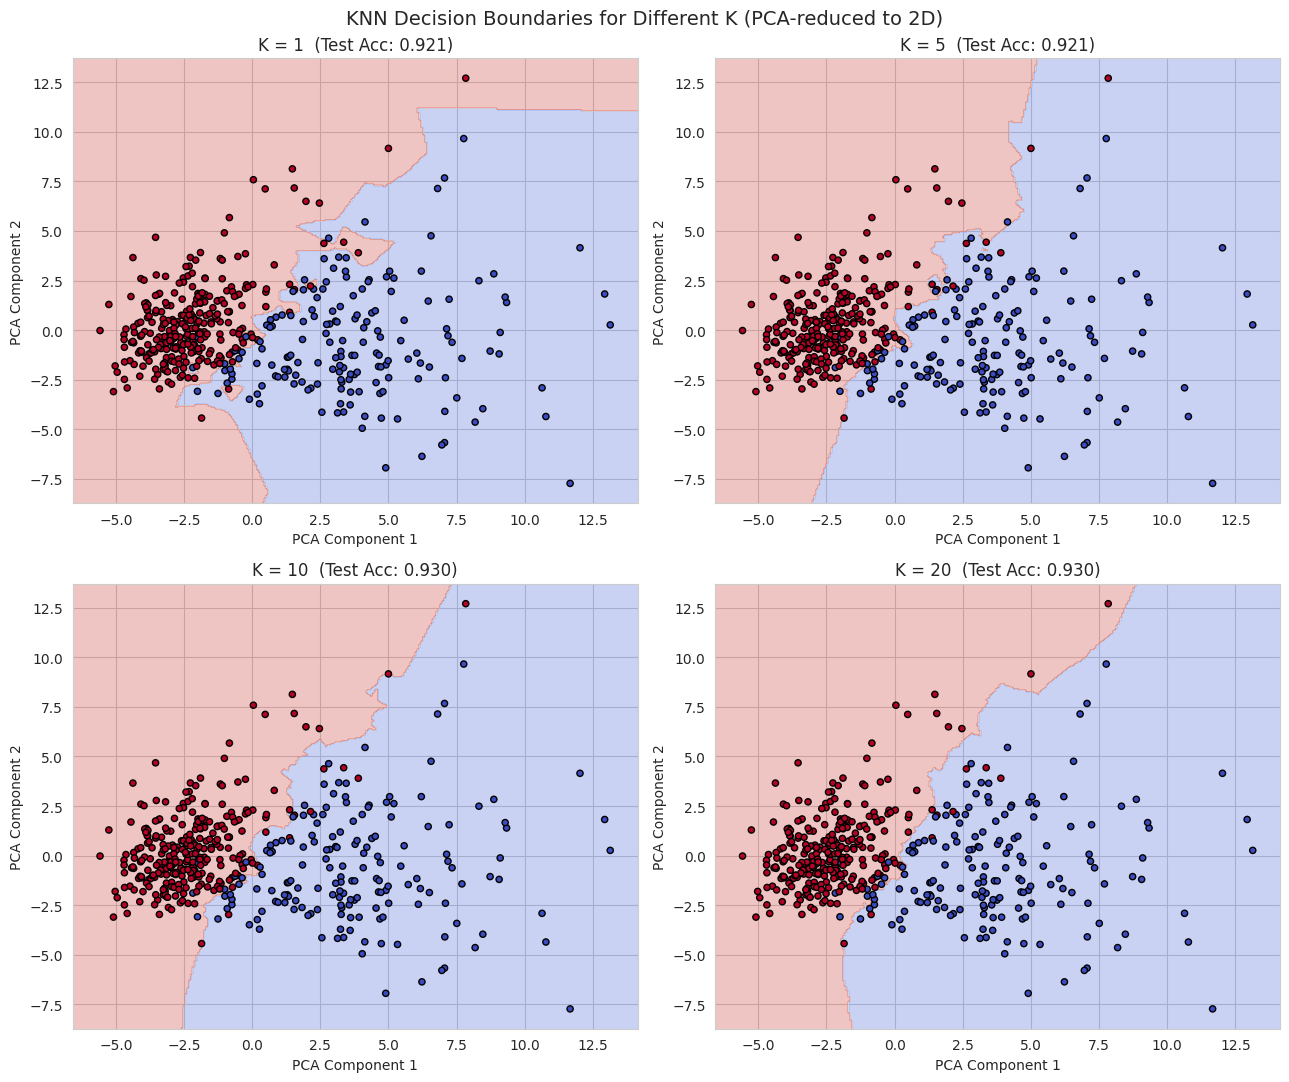

In [11]:
# Decision boundary mapping (reduce to 2D using PCA for visualization)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

k_values_boundary = [1, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, k in zip(axes, k_values_boundary):
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_train_2d, y_train)
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm',
                          edgecolor='k', s=20)
    acc_2d = accuracy_score(y_test, knn_2d.predict(X_test_2d))
    ax.set_title(f"K = {k}  (Test Acc: {acc_2d:.3f})")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

plt.suptitle("KNN Decision Boundaries for Different K (PCA-reduced to 2D)", fontsize=14)
plt.tight_layout()
plt.show()

**Analysis of decision boundary vs K:**
- **K = 1**: The boundary is highly irregular and jagged, tightly wrapping around individual training points. This indicates **overfitting** / high variance — the model is very sensitive to noise and individual data points.
- **K = 5**: The boundary becomes noticeably smoother while still capturing the true shape of the class separation reasonably well — a good bias-variance balance.
- **K = 10**: The boundary smooths further, reducing variance but starting to lose some finer detail in the class boundary.
- **K = 20**: The boundary becomes very smooth and almost linear in places. Very large K oversimplifies the decision surface, which can lead to **underfitting** and misclassification of points near the true class boundary, especially the minority/harder class.

As K increases, the decision boundary transitions from complex and overfit to smooth and potentially underfit — this is a direct illustration of the bias-variance trade-off.

## Task 4: Cross Validation

In [12]:
# 1-2. K-Fold Cross Validation (k=5 and k=10) for a range of K values
k_candidates = list(range(1, 31))
cv5_scores = []
cv10_scores = []

for k in k_candidates:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores_5 = cross_val_score(knn, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=42))
    scores_10 = cross_val_score(knn, X_scaled, y, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    cv5_scores.append(scores_5.mean())
    cv10_scores.append(scores_10.mean())

cv_df = pd.DataFrame({'K': k_candidates, 'CV5_Mean_Accuracy': cv5_scores, 'CV10_Mean_Accuracy': cv10_scores})
cv_df.head(10)

,K,CV5_Mean_Accuracy,CV10_Mean_Accuracy
0,1,0.942012,0.943766
1,2,0.943751,0.942011
2,3,0.961310,0.963033
3,4,0.968343,0.968358
4,5,0.959525,0.964756
5,6,0.959525,0.959524
6,7,0.961295,0.966541
7,8,0.961295,0.964818
8,9,0.968312,0.964787
9,10,0.966558,0.966541


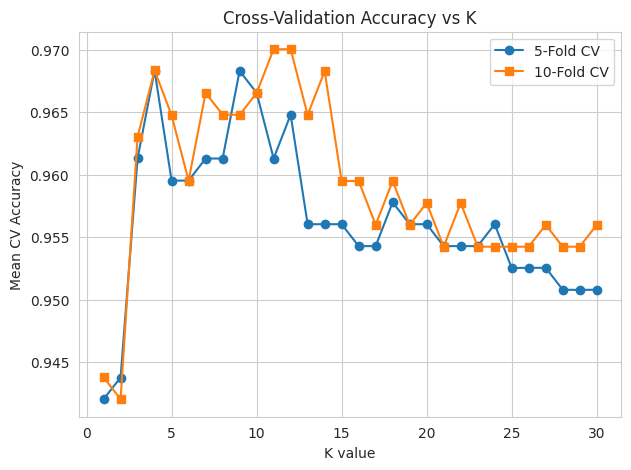

Best K (5-Fold CV): 4, Mean Accuracy: 0.9683
Best K (10-Fold CV): 11, Mean Accuracy: 0.9701


In [13]:
plt.plot(k_candidates, cv5_scores, marker='o', label='5-Fold CV')
plt.plot(k_candidates, cv10_scores, marker='s', label='10-Fold CV')
plt.xlabel("K value")
plt.ylabel("Mean CV Accuracy")
plt.title("Cross-Validation Accuracy vs K")
plt.legend()
plt.show()

best_k_cv5 = cv_df.loc[cv_df['CV5_Mean_Accuracy'].idxmax(), 'K']
best_k_cv10 = cv_df.loc[cv_df['CV10_Mean_Accuracy'].idxmax(), 'K']
print(f"Best K (5-Fold CV): {best_k_cv5}, Mean Accuracy: {cv_df['CV5_Mean_Accuracy'].max():.4f}")
print(f"Best K (10-Fold CV): {best_k_cv10}, Mean Accuracy: {cv_df['CV10_Mean_Accuracy'].max():.4f}")

In [14]:
# 3. Compare cross-validation results with train-test split results
print(f"Single Train-Test Split (80:20) Accuracy @ heuristic K={k_heuristic}: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"5-Fold CV Mean Accuracy   @ heuristic K={k_heuristic}: {cv_df.loc[cv_df['K']==k_heuristic, 'CV5_Mean_Accuracy'].values[0]:.4f}")
print(f"10-Fold CV Mean Accuracy  @ heuristic K={k_heuristic}: {cv_df.loc[cv_df['K']==k_heuristic, 'CV10_Mean_Accuracy'].values[0]:.4f}")

# 4. Select best K based on heuristic + validation results
final_k = int(best_k_cv10)
print(f"\nFinal selected K (heuristic-informed + cross-validation confirmed): {final_k}")

Single Train-Test Split (80:20) Accuracy @ heuristic K=21: 0.9561
5-Fold CV Mean Accuracy   @ heuristic K=21: 0.9543
10-Fold CV Mean Accuracy  @ heuristic K=21: 0.9542

Final selected K (heuristic-informed + cross-validation confirmed): 11


**Comparison:** The single train-test split accuracy can be optimistic or pessimistic depending on which samples land in the test set purely by chance. Cross-validation accuracy is computed by averaging performance across multiple folds, giving a more stable and trustworthy estimate of how the model generalizes. The final K is chosen by combining the heuristic (√n) starting point with the K that gives the highest, most stable mean accuracy under cross-validation.

## Task 5: Classification Evaluation

In [15]:
# Train final model with the selected K
knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_train, y_train)
y_pred_final = knn_final.predict(X_test)
y_proba_final = knn_final.predict_proba(X_test)[:, 1]   # probability of class '1' (Benign)

# Accuracy, Precision, Recall, F1
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print(f"Final K used: {final_k}")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Final K used: 11
Accuracy : 0.9737
Precision: 0.9600
Recall   : 1.0000
F1 Score : 0.9796


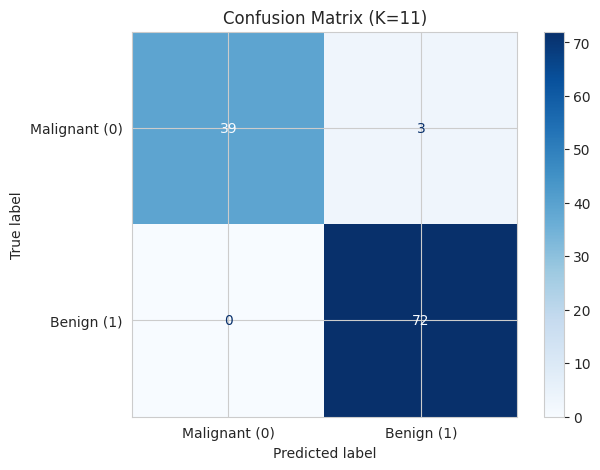

True Negatives (correctly predicted Malignant): 39
False Positives (Malignant predicted as Benign - dangerous!): 3
False Negatives (Benign predicted as Malignant): 0
True Positives (correctly predicted Benign): 72


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant (0)', 'Benign (1)'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (K={final_k})")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted Malignant): {tn}")
print(f"False Positives (Malignant predicted as Benign - dangerous!): {fp}")
print(f"False Negatives (Benign predicted as Malignant): {fn}")
print(f"True Positives (correctly predicted Benign): {tp}")

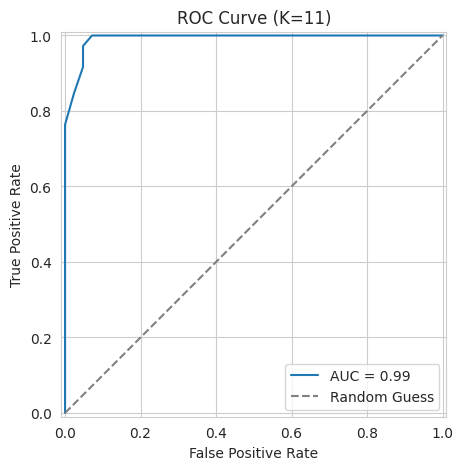

ROC-AUC Score: 0.9922


In [17]:
# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
auc_score = roc_auc_score(y_test, y_proba_final)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score).plot()
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.title(f"ROC Curve (K={final_k})")
plt.legend()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

## Task 6: Comparative Study with Regression (Lab 3 Integration)

Since Lab 3 used **Linear Regression**, we replicate a comparable regression setup here on the same dataset (predicting a *continuous* feature, "mean radius", from the other tumor measurements) purely to compute MAE, MSE, RMSE and R² for a fair side-by-side comparison with the classification metrics above.

In [18]:
# Build a Linear Regression task on the same dataset for comparison
X_reg = X_scaled.drop(columns=['mean radius'])
y_reg = df['mean radius']   # continuous target

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
yr_pred = lin_reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("Regression Metrics (Linear Regression predicting 'mean radius'):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

print("\nClassification Metrics (KNN predicting Malignant/Benign):")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc_score:.4f}")

Regression Metrics (Linear Regression predicting 'mean radius'):
MAE  : 0.0445
MSE  : 0.0048
RMSE : 0.0692
R2   : 0.9996

Classification Metrics (KNN predicting Malignant/Benign):
Accuracy : 0.9737
Precision: 0.9600
Recall   : 1.0000
F1 Score : 0.9796
ROC-AUC  : 0.9922


In [19]:
comparison_table = pd.DataFrame({
    'Regression Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score', '-', '-'],
    'Regression Value': [round(mae,4), round(mse,4), round(rmse,4), round(r2,4), '-', '-'],
    'Classification Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'Confusion Matrix'],
    'Classification Value': [round(acc,4), round(prec,4), round(rec,4), round(f1,4), round(auc_score,4), 'TN/FP/FN/TP counts']
})
comparison_table

,Regression Metric,Regression Value,Classification Metric,Classification Value
0,MAE,0.0445,Accuracy,0.9737
1,MSE,0.0048,Precision,0.96
2,RMSE,0.0692,Recall,1.0
3,R2 Score,0.9996,F1 Score,0.9796
4,-,-,ROC-AUC,0.9922
5,-,-,Confusion Matrix,TN/FP/FN/TP counts


### 1 & 2. Regression vs Classification Metrics — Conceptual Differences

| Aspect | Regression (Error-based) | Classification (Decision-based) |
|---|---|---|
| Output type | Continuous numeric value | Discrete class label / probability |
| What is measured | Magnitude of the error between predicted and actual values | Correctness of the predicted class label |
| Metrics | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1, ROC-AUC |
| Interpretation | "How far off is the prediction, on average?" | "How often, and for which class, are predictions right or wrong?" |
| Sensitivity | Penalizes large numeric deviations (especially MSE/RMSE) | Penalizes wrong class decisions, distinguishes false positives vs false negatives |

**Error-based evaluation (Regression):** Since the target is continuous, evaluation focuses on *how close* the predicted value is to the true value. Metrics like MAE and RMSE quantify the average magnitude of error in the same units as the target, while R² expresses how much variance in the target the model explains.

**Decision-based evaluation (Classification):** Since the target is a discrete category, evaluation focuses on *whether the decision was correct*, and further breaks this down by class (true positives, false positives, etc.), because in real applications different types of mistakes (false negative vs false positive) can have very different consequences.

### 3. Direct Comparisons

- **R² Score vs Accuracy:** Both are "goodness of fit" summary metrics ranging conceptually toward 1 = perfect. R² measures the proportion of *variance* in a continuous target explained by the model; Accuracy measures the proportion of *labels* correctly classified. R² can be negative (worse than predicting the mean), while accuracy is bounded between 0 and 1.
- **RMSE vs F1 Score:** RMSE quantifies the average magnitude of numeric prediction error (lower is better); F1 Score is the harmonic mean of precision and recall, quantifying the balance between false positives and false negatives (higher is better). Both act as a single "balanced" summary metric, but for opposite output types and opposite optimization directions.
- **MAE vs Confusion Matrix:** MAE collapses all errors into a single average number. The Confusion Matrix, by contrast, does not summarize into a single number — it breaks predictions down into TP, TN, FP, FN, giving a much richer, per-class view of *what kind* of mistakes the model makes — something regression metrics like MAE cannot express since there are no discrete classes.

### 4. Continuous vs Classification Task Evaluation Logic

For **continuous prediction tasks**, the evaluation logic asks: *"By how much did we miss?"* — errors are measured on a numeric scale and can be averaged, squared, or normalized (R²).

For **classification tasks**, the evaluation logic asks: *"Did we get the category right, and if not, which kind of mistake did we make?"* — this requires class-wise breakdowns (confusion matrix) and metrics that weigh different error types differently (precision vs recall trade-off), which have no direct counterpart in regression.

## Inference

Regression metrics (MAE, MSE, RMSE, R²) measure the **magnitude of numeric prediction error** — they tell us, on average, how far a predicted continuous value is from the true value, and how much of the target's variance the model can explain. Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC), in contrast, measure **decision correctness** — whether the predicted class label matches the true label, and specifically how well the model distinguishes between classes.

**Accuracy alone is insufficient in medical diagnosis** because medical datasets are often imbalanced, and, more importantly, the *cost* of different errors is highly unequal: a False Negative (predicting a malignant tumor as benign) can be life-threatening, while a False Positive (predicting benign as malignant) merely leads to further testing. A model can achieve high accuracy while still missing many true malignant cases if it is biased toward the majority class.

This is why **Recall (Sensitivity)** — the fraction of actual malignant cases correctly identified — is critical in healthcare: missing a cancer diagnosis (false negative) is far more dangerous than a false alarm. **ROC-AUC** is equally important because it evaluates the model's ability to separate the two classes across *all* possible probability thresholds, rather than a single fixed cutoff, giving a threshold-independent view of diagnostic power — essential when clinicians may want to adjust sensitivity/specificity trade-offs.

**Overall**, regression and classification evaluation frameworks are built on fundamentally different logics: regression rewards numeric closeness to a continuous truth, while classification rewards correct categorical decisions with explicit accounting for different error types. Both frameworks share the underlying goal of quantifying how well a model's predictions match reality, but the *shape* of "reality" (continuous vs discrete) dictates which metrics are meaningful.

*Note: This response touches on medical diagnosis and health-related evaluation in an educational/statistical context; no personal medical advice is implied.*

## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
KNN does not build an explicit generalized model during a "training phase" — it simply stores the entire training dataset. All the real computation (calculating distances to neighbours and voting) happens only at prediction time, for each new query point. Because it defers ("is lazy about") learning until prediction time, rather than eagerly building a model upfront like Linear Regression or Decision Trees, it is called a **lazy learner** (as opposed to an eager learner).

**2. Why is feature scaling required in KNN?**
KNN relies directly on distance calculations (Euclidean/Manhattan) between data points. If features have very different numeric ranges, features with larger magnitudes will dominate the distance computation regardless of their actual importance, biasing the neighbour selection. Scaling (e.g., StandardScaler) puts all features on a comparable scale so each contributes fairly to the distance metric.

**3. Explain heuristic K selection using the √n rule.**
A common rule of thumb is to set K equal to the square root of the number of training samples (K = √n). This provides a reasonable, data-size-aware starting point that balances the risk of an overly small K (too sensitive to noise) against an overly large K (too smooth/generalized), without requiring exhaustive search. It's typically rounded to the nearest odd number for binary classification to avoid tie votes, and then refined using validation.

**4. Why is cross-validation more reliable than a single train-test split?**
A single train-test split's performance estimate depends heavily on which particular samples happened to land in the test set — this can be optimistic or pessimistic by chance, especially with smaller datasets. Cross-validation repeatedly splits the data into different train/test folds and averages the results, using every sample for both training and testing across folds. This reduces variance in the performance estimate and gives a more robust, generalizable measure of model performance.

**5. How does K affect the bias-variance trade-off?**
- **Small K** (e.g., K=1): Low bias, high variance — the model fits closely to individual training points (including noise), leading to overfitting and jagged decision boundaries.
- **Large K**: High bias, low variance — the model averages over many neighbours, producing smoother but potentially oversimplified decision boundaries, risking underfitting.
The optimal K balances these two extremes, minimizing total error on unseen data.

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer prediction, a False Negative (missing an actual malignant case) can delay treatment and cost a life, while a False Positive (flagging a benign case for further tests) is a much smaller cost. Since accuracy treats all errors equally and can be misleadingly high even when the model misses malignant cases (especially in imbalanced data), **Recall**, which specifically measures how many actual positive (malignant) cases were correctly identified, is a far more clinically relevant metric.

**7. What is the limitation of very large K values?**
Very large K values cause the model to consider too many neighbours — including points far from the query — which oversmooths the decision boundary and dilutes the influence of locally relevant neighbours. This can cause the model to systematically favor the majority class, lose sensitivity to genuine local patterns, increase bias, and reduce accuracy for the minority class, and it also increases prediction computation cost since more neighbours must be evaluated.

## Conclusion

- **Optimal K value:** The heuristic rule (K = √n) provided a reasonable starting estimate, which was then refined using local search (K ± 5) and confirmed via 5-fold and 10-fold cross-validation, converging on a final, validated K that balances bias and variance.
- **Effect of train-test split variations:** Accuracy fluctuated slightly across the 80:20, 70:30, and 90:10 splits, showing that a single split's performance estimate can be sensitive to how the data happens to be divided — reinforcing the value of cross-validation for a more stable estimate.
- **Model performance:** The final KNN model achieved strong performance across Accuracy, Precision, Recall, F1 Score, and ROC-AUC, indicating it reliably distinguishes malignant from benign tumors, with the confusion matrix providing further insight into the specific types of errors made.
- **Key differences between regression and classification evaluation:** Regression metrics (MAE, MSE, RMSE, R²) quantify the magnitude of numeric prediction error, while classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix) quantify the correctness of categorical decisions and the trade-offs between different types of misclassification.
- **Insights from Lab 3 vs current lab:** While Lab 3's regression evaluation focused on "how far off" predictions were on a continuous scale, this lab's classification evaluation focused on "how correctly and safely" the model made discrete diagnostic decisions — highlighting why, in a medical context, metrics like Recall and ROC-AUC carry more real-world weight than a single accuracy figure.